# nb09 — строгость отбора: первый рычаг, который реально двигает edge

nb07 §0b нашёл то, чего мы не искали. Порог ADF оказался не технической деталью,
а самой сильной ручкой во всей конструкции:

| порог t | % пар | сделок | GROSS % | ход, σ | NET taker % |
|---|---|---|---|---|---|
| −4.6 | 0.7 | 3179 | **+0.124** | **+0.127** | **−0.086** |
| −4.2 | 1.7 | 7119 | +0.078 | +0.073 | −0.132 |
| −3.8 | 3.9 | 16055 | +0.051 | +0.067 | −0.159 |
| −3.545 (nb06) | 6.4 | 25175 | +0.019 | +0.048 | −0.191 |
| −3.2 | 12.2 | 43618 | −0.003 | +0.033 | −0.213 |
| −2.8 | 22.9 | 73340 | −0.028 | +0.015 | −0.238 |
| нет фильтра | 90.2 | 197192 | **−0.075** | **−0.033** | −0.285 |

(L=7 дней, TRAIN, ежедневный рефит.) Зависимость монотонная, `corr(строгость,
ход в σ) = +0.80`, и **без фильтра коинтеграции edge отрицателен** — то есть тест
на стационарность действительно несёт информацию, а nb06 просто стоял на слишком
мягкой отсечке (порог был откалиброван на 5% ложных срабатываний, что для 903 пар
означает ~45 ложных пар в день — их шум и топил сигнал).

**Но радоваться рано, потому что есть три способа получить этот результат ложно:**

1. **Отбор по хвосту.** Мы смотрим на 0.7% самых крайних значений t. На случайных
   данных это тоже даёт «самые возвратные» серии — просто по построению. Лечится
   прогоном синтетики при **каждом** пороге, а не только при базовом.
2. **Микроструктурный шум.** ADF даёт максимально отрицательную t именно тем
   парам, где спред дёргается на каждом баре, — а самый частый источник такого
   дёргания это отскок цены между bid и ask, который неторгуем. Лечится
   **задержкой исполнения**: если edge исчезает при входе на бар позже, он был
   шумом.
3. **Малая выборка и несколько пар.** 3179 сделок могут прийти с десятка пар.
   Лечится кластеризацией статистики по паре и разбором вклада.

Все три проверки — ниже.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
from _engine import *
from dataclasses import replace
from itertools import combinations
import time

MIN_DVOL_M = 5.0
STABLES = ["USDCUSDT", "USDEUSDT", "DAIUSDT", "TUSDUSDT", "FDUSDUSDT"]
px = load_panel("close", "1h")
dv = load_panel("dollarvol", "1h")
daily_m = dv.median() * 24 / 1e6
liq = sorted([s for s in px.columns if daily_m[s] >= MIN_DVOL_M and s not in STABLES])
LP = np.log(px.loc[TRAIN[0]:TRAIN[1], liq]).iloc[:-1]
PAIRS = [((a, b) if daily_m[a] <= daily_m[b] else (b, a)) for a, b in combinations(liq, 2)]
bk = Book(LP, liq, PAIRS)
bk_n = bk.with_panel(shuffled(bk.M, seed=99))
COST = ROUND_TRIP_BPS / 100
LD = [3, 7]
REF, REF_N = {}, {}
for L in LD:
    n = bk.nbars(L)
    REF[L] = refit(bk, n, -3.5)          # порог здесь неважен, меняем его позже
    REF_N[L] = refit(bk_n, n, -3.5)
print(f"пар {len(bk.PAIRS)}, часов {len(bk.index)}; рефиты готовы для L={LD}")


def clustered_t(d, col="gross"):
    """t-статистика среднего с кластеризацией по паре (n завышать нельзя)."""
    m = d.groupby("pair")[col].mean()
    if len(m) < 3:
        return np.nan, len(m)
    return float(m.mean() / (m.std(ddof=1) / np.sqrt(len(m)))), len(m)

пар 903, часов 13151; рефиты готовы для L=[3, 7]


## 1. Расширенная сетка строгости, реальность против синтетики при КАЖДОМ пороге

Ключ к честности здесь один: синтетика проходит **тот же самый отбор по хвосту**.
Если рост edge со строгостью — это просто эффект «взять самые крайние t», он
воспроизведётся и на перемешанных данных, и разница останется нулевой.

Значимость считаем с кластеризацией по паре: сделок много, но они не независимы —
одна и та же пара даёт десятки сделок, и её особенность размножается по всей
выборке. Кластерная t-статистика считает единицей наблюдения пару, а не сделку.

  L=3д thr=-6.5: сделок 116 (синт 40), ход +0.3172σ против синт -0.5288σ, t=+1.35
  L=3д thr=-6.0: сделок 316 (синт 59), ход +0.2406σ против синт -0.2072σ, t=+1.68
  L=3д thr=-5.5: сделок 809 (синт 161), ход +0.0477σ против синт -0.2942σ, t=+0.30


  L=3д thr=-5.0: сделок 2269 (синт 443), ход +0.0491σ против синт -0.4349σ, t=+0.96
  L=3д thr=-4.6: сделок 5236 (синт 1122), ход +0.0353σ против синт -0.2159σ, t=+1.03


  L=3д thr=-4.2: сделок 11914 (синт 2787), ход +0.0570σ против синт -0.1408σ, t=+3.06


  L=3д thr=-3.8: сделок 25653 (синт 7280), ход +0.0650σ против синт -0.0645σ, t=+4.61


  L=3д thr=-3.4: сделок 52537 (синт 16958), ход +0.0533σ против синт -0.0482σ, t=+5.16


...

  L=7д thr=-3.0: сделок 57520 (синт 20546), ход +0.0255σ против синт +0.0050σ, t=-4.07


  L=7д thr=-2.5: сделок 99219 (синт 42695), ход +0.0071σ против синт +0.0059σ, t=-6.17


  L=7д thr=нет: сделок 197192 (синт 104041), ход -0.0326σ против синт -0.0041σ, t=-10.82

СТРОГОСТЬ ОТБОРА: РЕАЛЬНОСТЬ ПРОТИВ СИНТЕТИКИ ПРИ КАЖДОМ ПОРОГЕ
 L, дн порог  % пар  сделок  пар в игре  GROSS %   ход σ  синт ход σ  разница σ  синт сделок  t (кластер по паре)  медиана ч
     3  -6.5   0.02     116          63   0.1738  0.3172     -0.5288     0.8460           40                 1.35          5
     3  -6.0   0.05     316         151   0.0791  0.2406     -0.2072     0.4478           59                 1.68          5
     3  -5.5   0.12     809         330  -0.1101  0.0477     -0.2942     0.3419          161                 0.30          5
     3  -5.0   0.32    2269         642  -0.0018  0.0491     -0.4349     0.4840          443                 0.96          5
     3  -4.6   0.72    5236         852   0.0159  0.0353     -0.2159     0.2512         1122                 1.03          5
     3  -4.2   1.69   11914         897   0.0452  0.0570     -0.1408     0.1979         2787    

[saved] notebooks\statarb\_out\nb09_strictness.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb09_strictness.png')

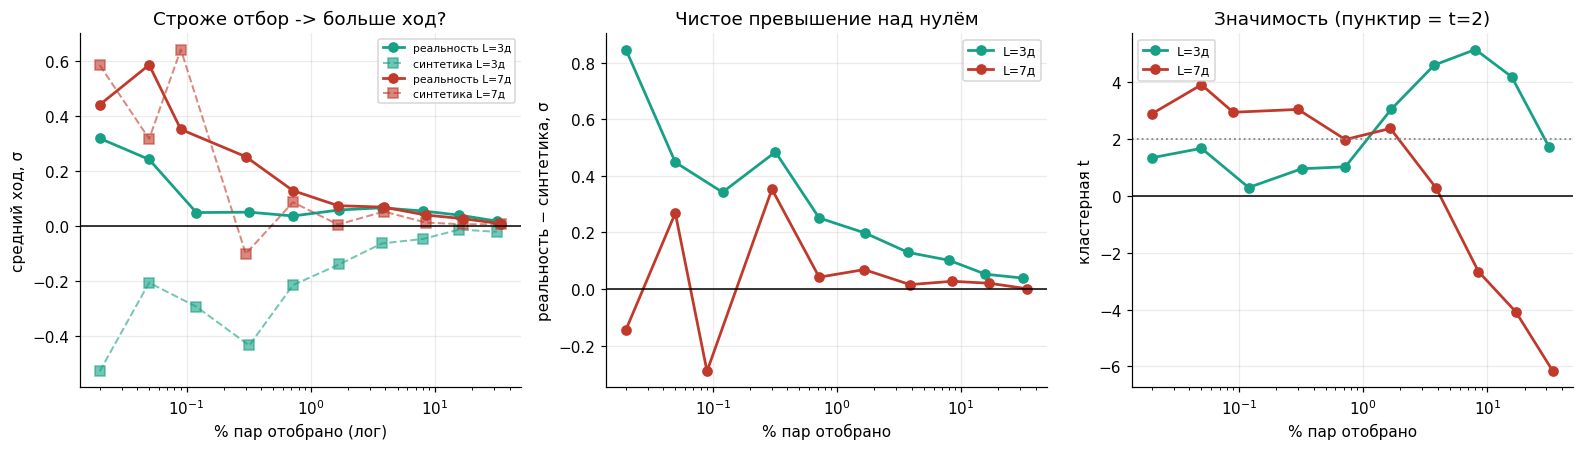

In [2]:
GRID = [-6.5, -6.0, -5.5, -5.0, -4.6, -4.2, -3.8, -3.4, -3.0, -2.5, np.inf]
rows = []
for L in LD:
    for thr in GRID:
        dr = sweep(bk, replace(REF[L], thr=thr), "REFIT", cost_pct=COST)
        dn = sweep(bk_n, replace(REF_N[L], thr=thr), "REFIT", cost_pct=COST)
        if len(dr) < 30:
            continue
        tr, kr = clustered_t(dr)
        rows.append({"L, дн": L, "порог": round(thr, 2) if np.isfinite(thr) else "нет",
                     "% пар": round(replace(REF[L], thr=thr).sel.mean()*100, 2),
                     "сделок": len(dr), "пар в игре": kr,
                     "GROSS %": round(dr.gross.mean(), 4),
                     "ход σ": round(dr.sigma.mean(), 4),
                     "синт ход σ": round(dn.sigma.mean(), 4) if len(dn) else np.nan,
                     "разница σ": round(dr.sigma.mean() - dn.sigma.mean(), 4) if len(dn) else np.nan,
                     "синт сделок": len(dn),
                     "t (кластер по паре)": round(tr, 2),
                     "медиана ч": int(dr.hours.median())})
        print(f"  L={L}д thr={rows[-1]['порог']}: сделок {len(dr)} (синт {len(dn)}), "
              f"ход {dr.sigma.mean():+.4f}σ против синт {dn.sigma.mean():+.4f}σ, t={tr:+.2f}")
GR = pd.DataFrame(rows)
print("\nСТРОГОСТЬ ОТБОРА: РЕАЛЬНОСТЬ ПРОТИВ СИНТЕТИКИ ПРИ КАЖДОМ ПОРОГЕ")
print(GR.to_string(index=False))
print()
for L in LD:
    d = GR[GR["L, дн"] == L]
    print(f"L={L}д:")
    print(f"  реальность: ход от {d['ход σ'].min():+.4f}σ до {d['ход σ'].max():+.4f}σ")
    print(f"  синтетика:  ход от {d['синт ход σ'].min():+.4f}σ до {d['синт ход σ'].max():+.4f}σ")
    fin = d[d["порог"] != "нет"]
    c1 = np.corrcoef(fin["% пар"], fin["ход σ"])[0, 1]
    c2 = np.corrcoef(fin["% пар"], fin["синт ход σ"])[0, 1]
    print(f"  corr(доля отобранных, ход): реальность {c1:+.2f}, синтетика {c2:+.2f}")
    print(f"  -> {'у синтетики тренда НЕТ, рост реальный' if abs(c2) < 0.4 else 'ОСТОРОЖНО: синтетика показывает тот же тренд'}")
    b = d.sort_values("разница σ", ascending=False).iloc[0]
    print(f"  максимум превышения над синтетикой: порог {b['порог']} -> "
          f"{b['разница σ']:+.4f}σ, сделок {b['сделок']}, пар {b['пар в игре']}, "
          f"кластерная t={b['t (кластер по паре)']:+.2f}")
    print()

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))
for L, c in [(3, "#16a085"), (7, "#c0392b")]:
    d = GR[(GR["L, дн"] == L) & (GR["порог"] != "нет")]
    ax[0].plot(d["% пар"], d["ход σ"], "o-", lw=1.8, color=c, label=f"реальность L={L}д")
    ax[0].plot(d["% пар"], d["синт ход σ"], "s--", lw=1.3, alpha=0.6, color=c,
               label=f"синтетика L={L}д")
ax[0].axhline(0, color="black", lw=1); ax[0].set_xscale("log")
ax[0].set_xlabel("% пар отобрано (лог)"); ax[0].set_ylabel("средний ход, σ")
ax[0].set_title("Строже отбор -> больше ход?"); ax[0].legend(fontsize=7)
for L, c in [(3, "#16a085"), (7, "#c0392b")]:
    d = GR[(GR["L, дн"] == L) & (GR["порог"] != "нет")]
    ax[1].plot(d["% пар"], d["разница σ"], "o-", lw=1.8, color=c, label=f"L={L}д")
ax[1].axhline(0, color="black", lw=1); ax[1].set_xscale("log")
ax[1].set_xlabel("% пар отобрано"); ax[1].set_ylabel("реальность − синтетика, σ")
ax[1].set_title("Чистое превышение над нулём"); ax[1].legend(fontsize=8)
for L, c in [(3, "#16a085"), (7, "#c0392b")]:
    d = GR[(GR["L, дн"] == L) & (GR["порог"] != "нет")]
    ax[2].plot(d["% пар"], d["t (кластер по паре)"], "o-", lw=1.8, color=c, label=f"L={L}д")
ax[2].axhline(0, color="black", lw=1); ax[2].axhline(2, color="#7f8c8d", ls=":", lw=1.2)
ax[2].set_xscale("log"); ax[2].set_xlabel("% пар отобрано")
ax[2].set_ylabel("кластерная t"); ax[2].set_title("Значимость (пунктир = t=2)")
ax[2].legend(fontsize=8)
show("nb09_strictness")

## 2. Задержка исполнения — тест на микроструктурный шум

Самая опасная возможность: ADF даёт минимальную t тем парам, чей спред активнее
всего дёргается от бара к бару. А главный источник такого дёргания — отскок цены
последней сделки между bid и ask. Такой «возврат» неторгуем в принципе: чтобы его
взять, надо купить по ask и продать по bid, отдав ровно ту величину, которая его
и создала.

Проверка простая и жёсткая: **входим и выходим на N баров позже сигнала**. Отскок
имеет память в один бар, поэтому шумовой edge исчезает уже при задержке 1. А
настоящий возврат к среднему на горизонте 10 часов от переноса входа на час
почти не пострадает.

ЗАДЕРЖКА ИСПОЛНЕНИЯ
 L, дн  порог  задержка, ч  сделок  GROSS %   ход σ  синт σ  разница σ  t кластер  пар
     3   -5.0            0    2269  -0.0018  0.0491 -0.4349     0.4840       0.96  642
     3   -5.0            1    2084   0.0011  0.0733 -0.4524     0.5257      -0.28  642
     3   -5.0            2    1919  -0.0048  0.0844 -0.4257     0.5101      -0.83  642
     3   -5.0            4    1681   0.0096  0.0894 -0.3941     0.4835      -0.59  642
     3   -4.6            0    5236   0.0159  0.0353 -0.2159     0.2512       1.03  852
     3   -4.6            1    4797   0.0151  0.0361 -0.2355     0.2717       0.32  852
     3   -4.6            2    4433   0.0180  0.0598 -0.2124     0.2723       0.31  852
     3   -4.6            4    3892   0.0216  0.0707 -0.2281     0.2988       0.69  852
     3   -4.2            0   11914   0.0452  0.0570 -0.1408     0.1979       3.06  897
     3   -4.2            1   10934   0.0407  0.0435 -0.1713     0.2148       2.16  897
     3   -4.2          

WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb09_delay.png')

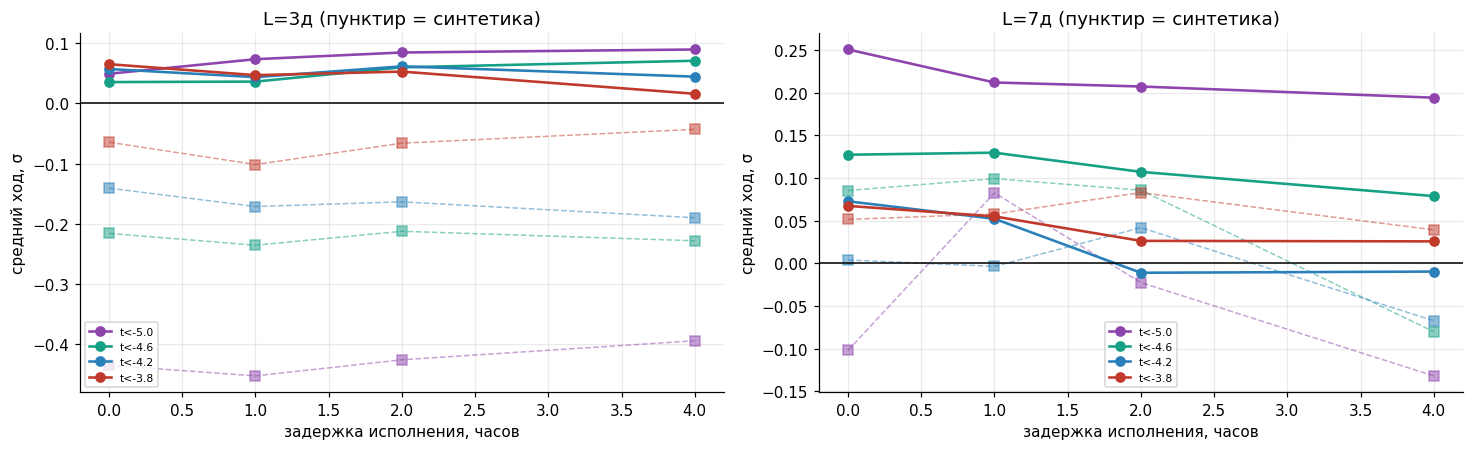

In [3]:
rows = []
for L in LD:
    for thr in [-5.0, -4.6, -4.2, -3.8]:
        for dl in [0, 1, 2, 4]:
            dr = sweep(bk, replace(REF[L], thr=thr), "REFIT", cost_pct=COST, delay=dl)
            dn = sweep(bk_n, replace(REF_N[L], thr=thr), "REFIT", cost_pct=COST, delay=dl)
            if len(dr) < 30:
                continue
            t_, k_ = clustered_t(dr)
            rows.append({"L, дн": L, "порог": thr, "задержка, ч": dl, "сделок": len(dr),
                         "GROSS %": round(dr.gross.mean(), 4),
                         "ход σ": round(dr.sigma.mean(), 4),
                         "синт σ": round(dn.sigma.mean(), 4) if len(dn) else np.nan,
                         "разница σ": round(dr.sigma.mean()-dn.sigma.mean(), 4) if len(dn) else np.nan,
                         "t кластер": round(t_, 2), "пар": k_})
DL = pd.DataFrame(rows)
print("ЗАДЕРЖКА ИСПОЛНЕНИЯ")
print(DL.to_string(index=False))
print()
for L in LD:
    for thr in [-5.0, -4.6, -4.2, -3.8]:
        d = DL[(DL["L, дн"] == L) & (DL["порог"] == thr)].sort_values("задержка, ч")
        if len(d) < 2:
            continue
        g0 = d[d["задержка, ч"] == 0]["ход σ"].iloc[0]
        g1 = d[d["задержка, ч"] == 1]["ход σ"].iloc[0]
        keep = g1/g0*100 if g0 != 0 else np.nan
        print(f"L={L}д thr={thr}: ход {g0:+.4f}σ -> {g1:+.4f}σ при задержке 1ч "
              f"(сохранилось {keep:.0f}%)")
print()
print("как читать: сохранилось <30% => edge был микроструктурным шумом;")
print("сохранилось >70% => возврат реальный и живёт дольше одного бара.")

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.2))
for k, L in enumerate(LD):
    for thr, c in [(-5.0, "#8e44ad"), (-4.6, "#16a085"), (-4.2, "#2980b9"), (-3.8, "#c0392b")]:
        d = DL[(DL["L, дн"] == L) & (DL["порог"] == thr)].sort_values("задержка, ч")
        if not len(d):
            continue
        ax[k].plot(d["задержка, ч"], d["ход σ"], "o-", lw=1.7, color=c, label=f"t<{thr}")
        ax[k].plot(d["задержка, ч"], d["синт σ"], "s--", lw=1.0, alpha=0.5, color=c)
    ax[k].axhline(0, color="black", lw=1)
    ax[k].set_xlabel("задержка исполнения, часов"); ax[k].set_ylabel("средний ход, σ")
    ax[k].set_title(f"L={L}д (пунктир = синтетика)"); ax[k].legend(fontsize=7)
show("nb09_delay")

## 3. Экономика: при каком косте это перестаёт быть убытком

Строгий отбор даёт положительный gross, а кост фиксирован. Значит существует
уровень костов, при котором стратегия выходит в ноль, и его надо назвать числом.

Сценарии:

| | комиссия | проскальзывание | round-trip |
|---|---|---|---|
| taker (наш базовый) | 5.5 bps | 5.0 bps | 21 bps |
| taker с реальным слипом | 5.5 | 1.5 | 14 bps |
| maker без ребейта | 1.0 | 2.0 | 6 bps |
| maker с ребейтом | 0.0 | 1.5 | 3 bps |

Второй сценарий появился не из желания улучшить картинку: nb08 §1 измерил
Roll-полуспред на минутных барах — **1.11 bps**. Наше базовое допущение 5.0 bps
проскальзывания на сторону завышено для этих символов примерно втрое.

Maker в mean-reversion устроен благоприятно: мы ставим лимит на уровне
расхождения, и нас наливают именно когда спред расходится дальше — то есть
исполнение приходит по цене **лучше** сигнальной. Но это надо будет проверять
отдельно на стакане, а не предполагать; здесь только арифметика.

In [4]:
# nb08 §1 измерил Roll-полуспред на 1m: 1.11 bps. Значит наше базовое допущение
# 5.0 bps проскальзывания на сторону завышено примерно в 3 раза для этих символов.
SCEN = {"taker 21 (базовый)": 0.21, "taker 14 (слип 1.5)": 0.14,
        "maker 6": 0.06, "maker+ребейт 3": 0.03}
rows = []
for L in LD:
    for thr in [-6.0, -5.5, -5.0, -4.6, -4.2, -3.8, -3.4]:
        d = sweep(bk, replace(REF[L], thr=thr), "REFIT", cost_pct=COST)
        if len(d) < 30:
            continue
        g = d.gross.mean()
        r = {"L, дн": L, "порог": thr, "сделок": len(d), "GROSS %": round(g, 4),
             "б/у кост, bps": round(g*100, 1)}
        for nm, c in SCEN.items():
            r[nm] = round(g - c, 4)
        rows.append(r)
EC = pd.DataFrame(rows)
print("NET НА СДЕЛКУ ПРИ РАЗНЫХ КОСТАХ (% от gross notional)")
print(EC.to_string(index=False))
print()
print("'б/у кост' — round-trip, при котором сделка выходит в ноль.")
print()
years = (bk.index[-1] - bk.index[0]).days / 365.25
F_POS = 0.02          # gross одной позиции = 2% капитала (как в nb04)
print(f"ПОРТФЕЛЬНЫЙ МАСШТАБ (за {years:.2f} года TRAIN, gross позиции {F_POS*100:.0f}% капитала)")
print("доходность = сделок/год x 2% x (net на сделку), без реинвеста и лимита gross\n")
for _, r in EC.iterrows():
    n_yr = r["сделок"]/years
    line = f"  L={r['L, дн']:>2}д thr={r['порог']:>5}: {n_yr:>6.0f} сделок/год ->"
    for nm in SCEN:
        line += f"  {nm.split()[0][:5]}:{n_yr*F_POS*r[nm]:+6.1f}%/год"
    print(line)
print()
print("ВАЖНО: это оценка сверху по обороту — она игнорирует лимит суммарного gross")
print("и просадку. Портфельная симуляция с очередью по |z| — следующий шаг (nb04).")

NET НА СДЕЛКУ ПРИ РАЗНЫХ КОСТАХ (% от gross notional)
 L, дн  порог  сделок  GROSS %  б/у кост, bps  taker 21 (базовый)  taker 14 (слип 1.5)  maker 6  maker+ребейт 3
     3   -6.0     316   0.0791            7.9             -0.1309              -0.0609   0.0191          0.0491
     3   -5.5     809  -0.1101          -11.0             -0.3201              -0.2501  -0.1701         -0.1401
     3   -5.0    2269  -0.0018           -0.2             -0.2118              -0.1418  -0.0618         -0.0318
     3   -4.6    5236   0.0159            1.6             -0.1941              -0.1241  -0.0441         -0.0141
     3   -4.2   11914   0.0452            4.5             -0.1648              -0.0948  -0.0148          0.0152
     3   -3.8   25653   0.0599            6.0             -0.1501              -0.0801  -0.0001          0.0299
     3   -3.4   52537   0.0495            4.9             -0.1605              -0.0905  -0.0105          0.0195
     7   -6.0     125   0.4687           46.9     

## 4. Устойчивость: это edge или пара удачных пар?

3179 сделок звучит солидно, но если они пришли с десяти пар и из двух месяцев,
доверять нечему. Смотрим:

- сколько пар и символов вообще участвует;
- вклад топ-10 пар в итог (если >50%, это не «стратегия», а «несколько пар»);
- по месяцам — сколько положительных;
- как ход зависит от глубины входа `z` и от времени в позиции.

L=7д, порог t<-4.6: 3179 сделок, gross +0.1241%, ход +0.1273σ
пар в игре 694, символов 43, кластерная t=+1.99

ТОП-10 ПАР ПО ВКЛАДУ В GROSS:
                       sum  size   mean
pair                                   
TRBUSDT/NEARUSDT    25.351    12  2.113
ORDIUSDT/SEIUSDT    22.405     8  2.801
TRBUSDT/DOGEUSDT    19.186     4  4.796
XMRUSDT/ENSUSDT     18.947    20  0.947
PEOPLEUSDT/BCHUSDT  18.940     6  3.157
TRBUSDT/XRPUSDT     18.349     7  2.621
XMRUSDT/TRBUSDT     17.500    20  0.875
TRBUSDT/INJUSDT     15.755     5  3.151
XMRUSDT/OPUSDT      15.122     9  1.680
XMRUSDT/CRVUSDT     15.094    13  1.161

вклад топ-10 пар: 47% итога (3% сделок)
вклад топ-25%: 286%
доля пар с положительным итогом: 56%

ПО МЕСЯЦАМ (gross):
             sum  size   mean
t_in                         
2024-01   -5.533    74 -0.075
2024-02   38.516   105  0.367
2024-03  111.352   360  0.309
2024-04  158.025   241  0.656
2024-05   34.751   123  0.283
2024-06   76.332   147  0.519
2024-07    5.747   1

[saved] notebooks\statarb\_out\nb09_robust.png


C:\Users\nvisary\AppData\Local\Temp\ipykernel_3252\3939366108.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bym = d.groupby(d.t_in.dt.to_period("M")).gross.agg(["sum", "size", "mean"])


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb09_robust.png')

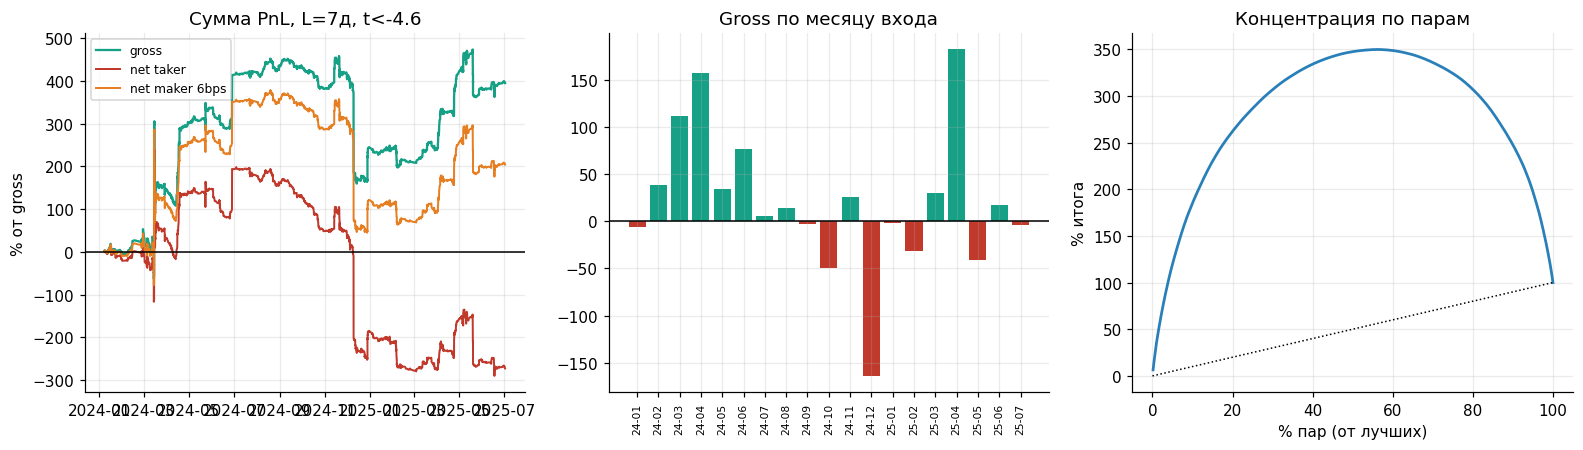

In [5]:
L, THR = 7, -4.6
d = sweep(bk, replace(REF[L], thr=THR), "REFIT", cost_pct=COST)
print(f"L={L}д, порог t<{THR}: {len(d)} сделок, gross {d.gross.mean():+.4f}%, "
      f"ход {d.sigma.mean():+.4f}σ")
t_, k_ = clustered_t(d)
print(f"пар в игре {k_}, символов {len(set(sum([p.split('/') for p in d.pair.unique()], [])))}, "
      f"кластерная t={t_:+.2f}")
print()
bypair = d.groupby("pair").gross.agg(["sum", "size", "mean"]).sort_values("sum", ascending=False)
tot = bypair["sum"].sum()
print("ТОП-10 ПАР ПО ВКЛАДУ В GROSS:")
print(bypair.head(10).round(3).to_string())
print(f"\nвклад топ-10 пар: {bypair.head(10)['sum'].sum()/tot*100:.0f}% итога "
      f"({bypair.head(10)['size'].sum()/len(d)*100:.0f}% сделок)")
print(f"вклад топ-25%: {bypair.head(max(len(bypair)//4,1))['sum'].sum()/tot*100:.0f}%")
print(f"доля пар с положительным итогом: {(bypair['sum']>0).mean()*100:.0f}%")
print()
bym = d.groupby(d.t_in.dt.to_period("M")).gross.agg(["sum", "size", "mean"])
print("ПО МЕСЯЦАМ (gross):")
print(bym.round(3).to_string())
print(f"положительных месяцев {(bym['sum']>0).sum()} из {len(bym)}, "
      f"по среднему {(bym['mean']>0).sum()} из {len(bym)}")
print()
d = d.assign(zb=pd.cut(d.z_in.abs(), [2, 2.25, 2.5, 3, 4]),
             hb=pd.cut(d.hours, [0, 4, 12, 24, 72, 400]))
print("ХОД ПО ГЛУБИНЕ ВХОДА:")
print(d.groupby("zb", observed=True).agg(сделок=("gross", "size"), gross=("gross", "mean"),
                                         ход_σ=("sigma", "mean")).round(4).to_string())
print("\nХОД ПО ВРЕМЕНИ В ПОЗИЦИИ:")
print(d.groupby("hb", observed=True).agg(сделок=("gross", "size"), gross=("gross", "mean"),
                                         ход_σ=("sigma", "mean")).round(4).to_string())

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))
ds = d.sort_values("t_in")
ax[0].plot(ds.t_in.values, ds.gross.cumsum().values, lw=1.5, color="#16a085", label="gross")
ax[0].plot(ds.t_in.values, ds.pnl.cumsum().values, lw=1.3, color="#c0392b", label="net taker")
ax[0].plot(ds.t_in.values, (ds.gross-0.06).cumsum().values, lw=1.3, color="#e67e22",
           label="net maker 6bps")
ax[0].axhline(0, color="black", lw=1); ax[0].legend(fontsize=8)
ax[0].set_title(f"Сумма PnL, L={L}д, t<{THR}"); ax[0].set_ylabel("% от gross")
ax[1].bar(range(len(bym)), bym["sum"].values,
          color=["#16a085" if v > 0 else "#c0392b" for v in bym["sum"].values])
ax[1].set_xticks(range(len(bym))); ax[1].set_xticklabels([str(p)[2:] for p in bym.index],
                                                         rotation=90, fontsize=7)
ax[1].axhline(0, color="black", lw=1); ax[1].set_title("Gross по месяцу входа")
sh = np.sort(bypair["sum"].values)[::-1]
ax[2].plot(np.arange(1, len(sh)+1)/len(sh)*100, np.cumsum(sh)/tot*100, lw=1.8, color="#2980b9")
ax[2].plot([0, 100], [0, 100], color="black", ls=":", lw=1)
ax[2].set_xlabel("% пар (от лучших)"); ax[2].set_ylabel("% итога")
ax[2].set_title("Концентрация по парам")
show("nb09_robust")

## 5. Итог

In [6]:
print("ГЛАВНОЕ\n")
for L in LD:
    g = GR[(GR["L, дн"] == L) & (GR["порог"] != "нет")]
    b = g.sort_values("разница σ", ascending=False).iloc[0]
    nof = GR[(GR["L, дн"] == L) & (GR["порог"] == "нет")]
    print(f"L={L}д:")
    print(f"  лучший порог {b['порог']}: ход {b['ход σ']:+.4f}σ, синтетика "
          f"{b['синт ход σ']:+.4f}σ, чистое превышение {b['разница σ']:+.4f}σ, "
          f"t={b['t (кластер по паре)']:+.2f} по {b['пар в игре']} парам")
    if len(nof):
        print(f"  без фильтра: ход {nof['ход σ'].iloc[0]:+.4f}σ "
              f"(синтетика {nof['синт ход σ'].iloc[0]:+.4f}σ)")
    dd = DL[(DL["L, дн"] == L) & (DL["порог"] == -4.6)].sort_values("задержка, ч")
    if len(dd) >= 2:
        print(f"  задержка 1ч при t<-4.6: ход {dd['ход σ'].iloc[0]:+.4f}σ -> "
              f"{dd['ход σ'].iloc[1]:+.4f}σ")
    e = EC[(EC["L, дн"] == L)].sort_values("б/у кост, bps", ascending=False).iloc[0]
    print(f"  максимальный безубыточный кост: {e['б/у кост, bps']:.1f} bps "
          f"при пороге {e['порог']} (наш taker 21 bps)")
    print()

ГЛАВНОЕ

L=3д:
  лучший порог -6.5: ход +0.3172σ, синтетика -0.5288σ, чистое превышение +0.8460σ, t=+1.35 по 63 парам
  без фильтра: ход -0.0136σ (синтетика -0.0159σ)
  задержка 1ч при t<-4.6: ход +0.0353σ -> +0.0361σ
  максимальный безубыточный кост: 7.9 bps при пороге -6.0 (наш taker 21 bps)

L=7д:
  лучший порог -5.0: ход +0.2507σ, синтетика -0.1020σ, чистое превышение +0.3526σ, t=+3.05 по 468 парам
  без фильтра: ход -0.0326σ (синтетика -0.0041σ)
  задержка 1ч при t<-4.6: ход +0.1273σ -> +0.1297σ
  максимальный безубыточный кост: 46.9 bps при пороге -6.0 (наш taker 21 bps)

